In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"timamohammedt","key":"e3ba513274c5dc95a21ba7b5cba32d9f"}'}

In [3]:
import os, shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle datasets download -d ismail703/insects
!unzip insects.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dragonfly/Dragonfly_151.jpg  
  inflating: Dragonfly/Dragonfly_152.jpg  
  inflating: Dragonfly/Dragonfly_153.jpg  
  inflating: Dragonfly/Dragonfly_154.jpg  
  inflating: Dragonfly/Dragonfly_155.jpg  
  inflating: Dragonfly/Dragonfly_156.jpg  
  inflating: Dragonfly/Dragonfly_157.jpg  
  inflating: Dragonfly/Dragonfly_158.jpg  
  inflating: Dragonfly/Dragonfly_159.jpg  
  inflating: Dragonfly/Dragonfly_16.jpg  
  inflating: Dragonfly/Dragonfly_160.jpg  
  inflating: Dragonfly/Dragonfly_161.jpg  
  inflating: Dragonfly/Dragonfly_162.jpg  
  inflating: Dragonfly/Dragonfly_163.jpg  
  inflating: Dragonfly/Dragonfly_164.jpg  
  inflating: Dragonfly/Dragonfly_165.jpg  
  inflating: Dragonfly/Dragonfly_166.jpg  
  inflating: Dragonfly/Dragonfly_167.jpg  
  inflating: Dragonfly/Dragonfly_168.jpg  
  inflating: Dragonfly/Dragonfly_169.jpg  
  inflating: Dragonfly/Dragonfly_17.jpg  
  inflating: Dragonfly/Dragonfly_170.jpeg  
  in

In [5]:
import os
print(os.listdir())

['.config', 'Beetle', 'Mosquito', 'Wasp', 'Spider', 'Ant', 'Butterfly', 'Ladybug', 'Fly', 'Bee', 'Dragonfly', 'insects_dataset', 'Grasshopper', 'insects.zip', 'sample_data']


In [6]:
import os, shutil, random

selected_classes = ['Grasshopper', 'Ant', 'Spider']

base_dir = "insects_dataset"
train_dir = os.path.join(base_dir, "train_data")
test_dir = os.path.join(base_dir, "test_data")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in selected_classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    images = os.listdir(cls)[:100]
    random.shuffle(images)

    for img in images[:5]:
        shutil.copy(os.path.join(cls, img),
                    os.path.join(test_dir, cls, img))

    for img in images[5:]:
        shutil.copy(os.path.join(cls, img),
                    os.path.join(train_dir, cls, img))

print("DONE")

DONE



# Stream Macroinvertebrates Image Classification
# ==================================
### This notebook demonstrates how to:
### 1. Load your dataset organized by class folders (without predefined splits)
### 2. Perform train/validation split in code
### 3. Augment data during training
### 4. Build transfer learning model with MobileNetV2 pretrained on ImageNet
### 5. Train, evaluate, and predict on new images


In [7]:
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities

[Errno 2] No such file or directory: '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities'
/content



## Step 0: Data Preparation
  
1.   Set the run time to one of the GPU options by selecting Runtime/Change Runtime type/...

2. Set the working folder for google colab notebook to the folder in the google drive.

3. Download stream invertebrates dataset from Kaggle and unzip it in google drive folder. You will find stream macroinvertebrates dataset in the unzipped archive folder ( You can do this outside colab as well).

4. Manually create a insects_dataset folder in Assets folder.

5. The images for each insect species in a separate folder, with folder name as the species name.

6. Pick any three insect species from the unzipped archive folder. The three species you select need to be other than the three species shown in this demo.

6. Create two new folders train_data and test_data in insects_dataset folder you just created in Step 4.

7. Move five images from each species you have selected into the test_data folder. Please note that they need to be moved, not copied. In total you would have 15 images in the test_data folder (5 images corresponding to each species).

8. Move remaining folders into train_data folder. Please note that you will not move each image, but move each folder containing remaining images into the train_data folder. After moving you will see three folders in train_data folder, with each folder containing several insect images corresponding to each insect species.



In [8]:
#! git clone https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates/data


In [9]:
#!unzip archive.zip

In [10]:
# Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset
DATASET_DIR = "insects_dataset/train_data"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

# === STEP 1: Load dataset and split ===

print("Loading dataset with 80/20 train-validation split...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)


# Class info
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes found:", class_names)
print("Number of classes:", num_classes)

Loading dataset with 80/20 train-validation split...
Found 2211 files belonging to 3 classes.
Using 1769 files for training.
Found 2211 files belonging to 3 classes.
Using 442 files for validation.
Classes found: ['Ant', 'Grasshopper', 'Spider']
Number of classes: 3


In [11]:
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [12]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

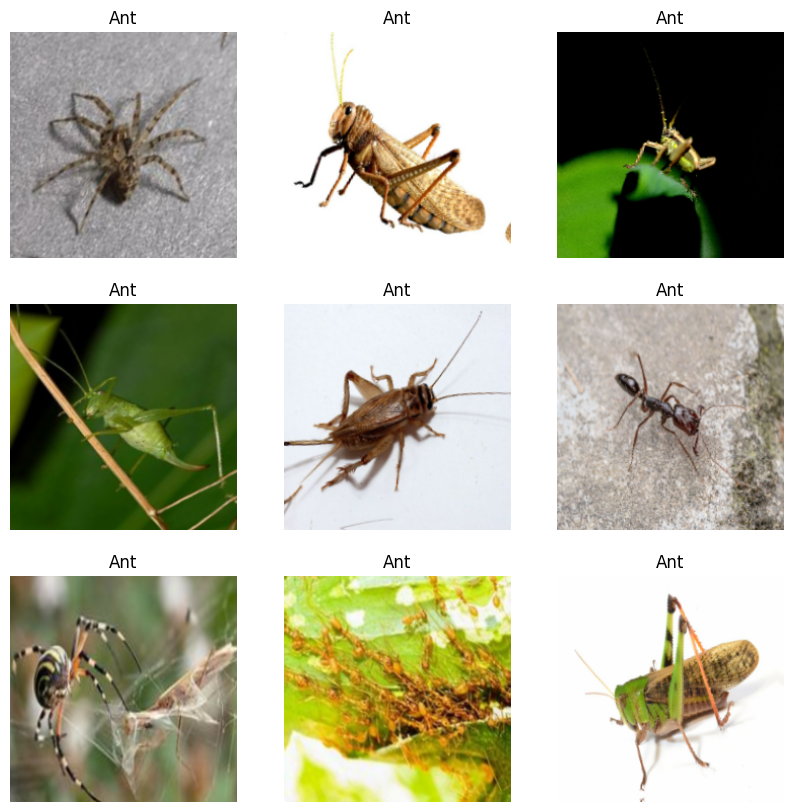

In [13]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.show()

In [14]:
# STEP 4: Build model

from tensorflow.keras import layers, models

# base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# model
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)

outputs = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
import os
from PIL import Image

def clean_dataset(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Deleting:", path)
                os.remove(path)

clean_dataset("insects_dataset/train_data")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


In [16]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
     38/Unknown 14s 187ms/step - accuracy: 0.8374 - loss: 0.3370

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 258ms/step - accuracy: 0.9363 - loss: 0.1441 - val_accuracy: 1.0000 - val_loss: 0.0101
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - accuracy: 0.9902 - loss: 0.0324 - val_accuracy: 0.9844 - val_loss: 0.0262
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 358ms/step - accuracy: 0.9951 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 0.0108
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.9861 - loss: 0.0339 - val_accuracy: 1.0000 - val_loss: 0.0072
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.9984 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.9984 - loss: 0.0044 - val_accuracy: 0.9946 - val_loss: 0.0081
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 625ms/step - accuracy: 0.9951 - loss: 0.0166 - val_accuracy: 0.9896 - val_loss: 0.0148
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.9918 - loss: 0.0272 - val_accuracy: 0.9839 - 

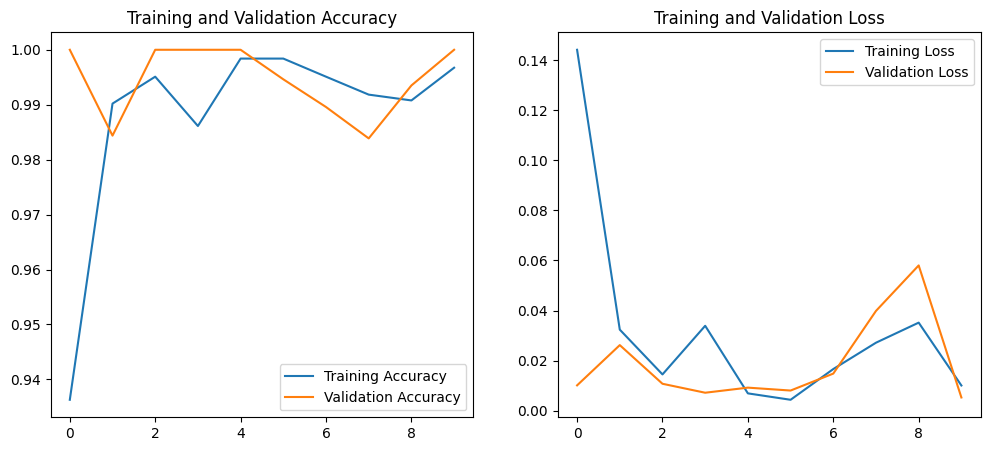

In [17]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [18]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 1.0000 - loss: 0.0035
Validation accuracy: 100.00%


In [19]:
# === STEP 9: Save the trained model ===
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

[Errno 2] No such file or directory: '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities'
/content
Model saved as 'macroinvertebrates_classifier.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 1200x1200 with 0 Axes>

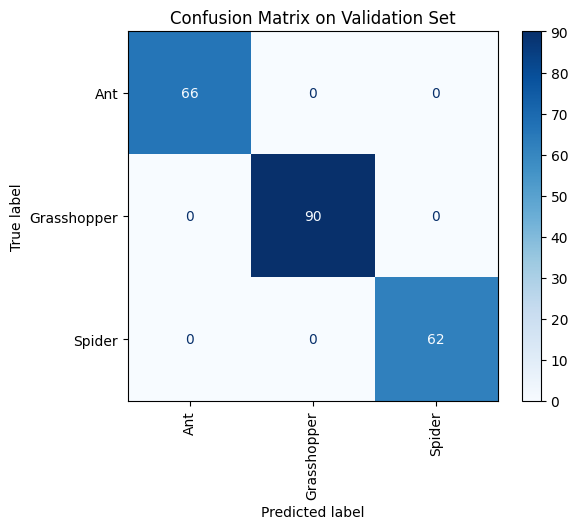

Weighted Precision: 1.0000
Weighted Recall:    1.0000
Weighted F1-score:  1.0000


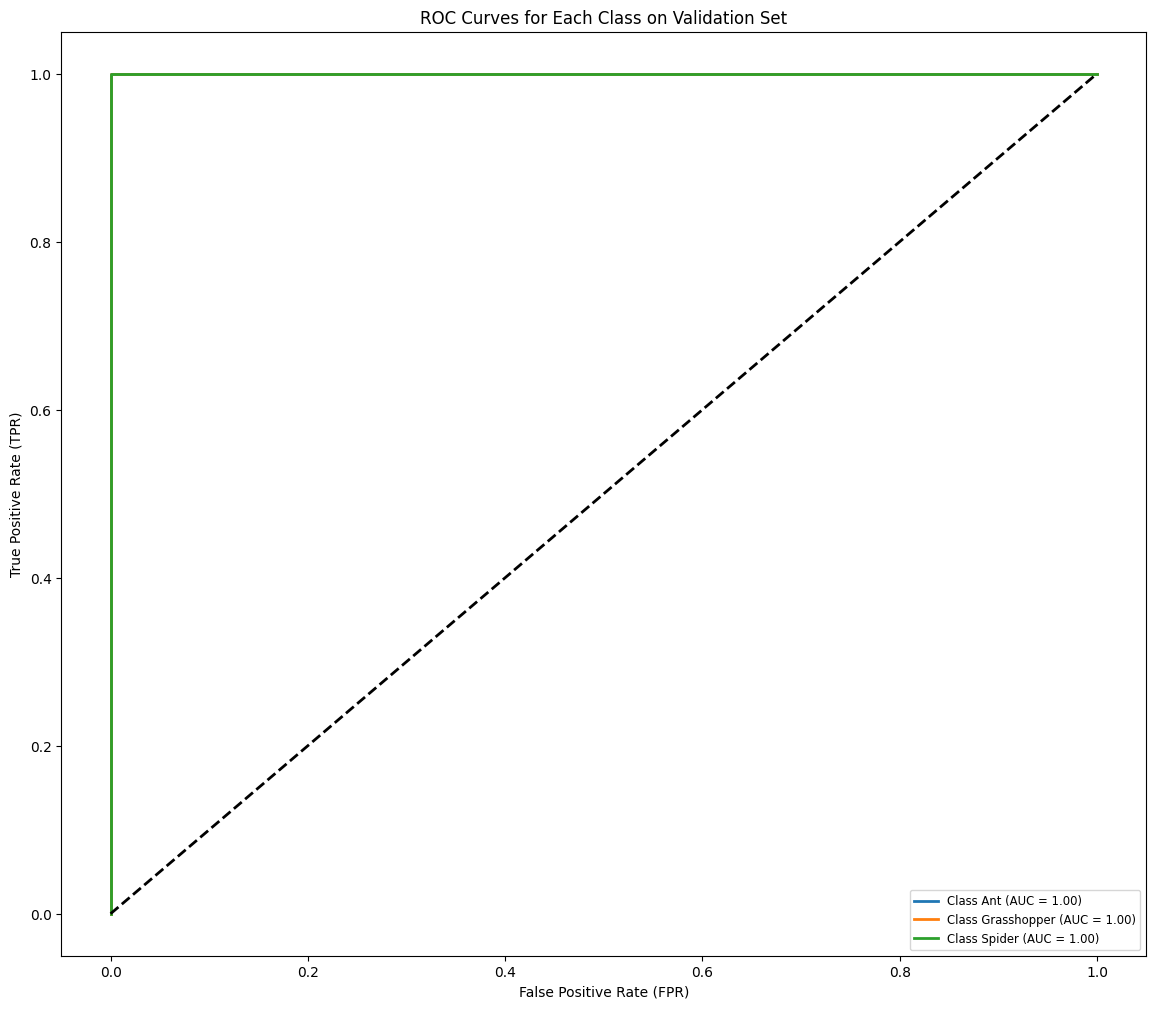

In [20]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



In [21]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities/Assets/insects_dataset/test_data'. Please add some images and rerun.
